In [1]:
import numpy as np
import matplotlib.pyplot as plt
# Project Path Setup
from setup_project_path import (
    check_and_add_project_path,
)  # Script to check and add project path
check_and_add_project_path()
from src.utils.common_funcs import  set_time_grid, cont_integral
from src.spec_dens.spec_dens import spec_dens_gapless

Project path successfully added.


In [2]:
Lambda = 50 #cutoff frequency
N_max = 100 #number of time steps
beta = 0 #inverse temperature
sharpness = 1 #sharpness is nu which is MULTIPLIED with (w-Lambda) in the exponent
delta_t = 0.1

# Define the spectral density
spec_dens = lambda x: spec_dens_gapless(x, cutoff_lower=-Lambda, cutoff_upper=Lambda, sharpness=sharpness) 


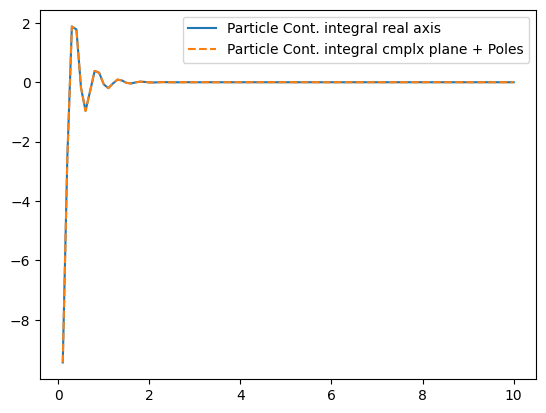

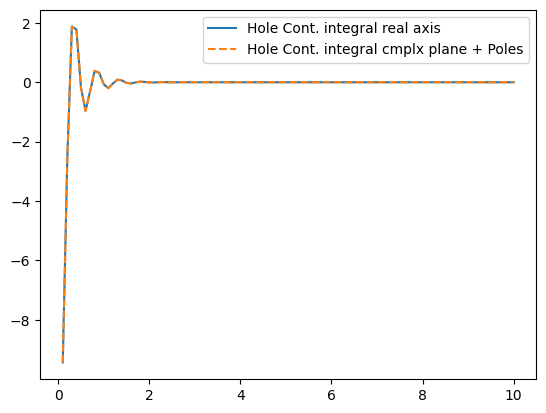

In [6]:
#create the time grid
time_grid = set_time_grid(N_max, delta_t)

#compute the continuous integral along REAL AXIS for only POSITIVE frequencies
cont_integral_particle = cont_integral(time_grid, beta, upper_cutoff=np.inf, spec_dens=spec_dens ,phi = 0.) #particle
cont_integral_hole = cont_integral(time_grid, -beta, upper_cutoff=np.inf, spec_dens = spec_dens,phi = 0.) #hole

#compute the continuous integral along COMPLEX AXIS for only POSITIVE frequencies
cont_integral_particle_cmplx = cont_integral(time_grid, beta, upper_cutoff=np.inf, spec_dens = spec_dens)#particle
cont_integral_hole_cmplx = cont_integral(time_grid, -beta, upper_cutoff=np.inf, spec_dens = spec_dens)#hole

#define function to compute the poles frequencies
def pole_freqs(Lambda, sharpness, k):
    return Lambda + 2.j * np.pi * 1/sharpness * (k+0.5)

#define kappa in terms of sharpness and Lambda
kappa = Lambda * sharpness/ (2 * np.pi)

#array that contains the poles frequencies
poles_freq_table_pos = np.array([pole_freqs(Lambda, sharpness, k) for k in range (1 + np.floor(np.tan(np.pi/4) * kappa - 0.5).astype(int))])
poles_freq_table_neg = np.array([pole_freqs(-Lambda, sharpness, k) for k in range (1 + np.floor(np.tan(np.pi/4) * kappa - 0.5).astype(int))])

#residues of spectral density
residue_spec_dens_pos = 1/(1 + np.exp(-sharpness * (poles_freq_table_pos + Lambda))) * 1/sharpness
residue_spec_dens_neg = 1/(1 + np.exp(sharpness * (poles_freq_table_neg - Lambda))) * 1/sharpness

#compute the kernels for positive and negative poles
kernel_particles_pos = - residue_spec_dens_pos * 2.j * np.pi * np.exp(1.j * time_grid[:,np.newaxis] * poles_freq_table_pos) * 1/( 1 + np.exp(beta * poles_freq_table_pos) )
kernel_particles_neg = - residue_spec_dens_neg * 2.j * np.pi * np.exp(1.j * time_grid[:,np.newaxis] * poles_freq_table_neg) * 1/( 1 + np.exp(beta * poles_freq_table_neg) )

#hstack the positive and negative poles
kernel_particles = np.hstack([kernel_particles_pos, kernel_particles_neg])

#sum over the poles to determine the contribution to the propagator
G_poles_pos = np.sum(kernel_particles_pos, axis = 1)
G_poles_neg = np.sum(kernel_particles_neg, axis = 1)

#plot
plt.plot(time_grid, cont_integral_particle , label= "Particle Cont. integral real axis")
plt.plot(time_grid, - G_poles_neg + G_poles_pos + cont_integral_particle_cmplx, label = "Particle Cont. integral cmplx plane + Poles", linestyle = "--")
plt.legend()
plt.show()

plt.plot(time_grid, cont_integral_hole , label= "Hole Cont. integral real axis")
plt.plot(time_grid, - G_poles_neg + G_poles_pos + cont_integral_hole_cmplx, label = "Hole Cont. integral cmplx plane + Poles", linestyle = "--")
plt.legend()
plt.show()


